# fashion_minst分类实战

In [21]:
import torch
from torchvision import datasets, transforms

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),#将PIL.Image变换成torch.Tensor，并且将像素值归一化到[0,1]
])

# 下载并加载训练数据集
full_train_dataset = datasets.FashionMNIST(root='./data', train=True, download=False, transform=transform)

# 从训练集中分出5000样本作为验证集
train_size = len(full_train_dataset) - 5000
val_size = 5000
#random_split打乱样本
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [train_size, val_size],generator=generator)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)  # batch_size是一个批次样本的数量
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

# 下载并加载测试数据集
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=False, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [22]:
print("训练集样本数：", len(train_dataset))
print("验证集样本数：", len(val_dataset))
print("测试集样本数：", len(test_dataset))

训练集样本数： 55000
验证集样本数： 5000
测试集样本数： 10000


In [23]:
full_train_dataset.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [24]:
print(train_dataset[1])
28 * 28

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.2235, 0.4235, 0.5608, 0.5647, 0.4157,
          0.2980, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.5255, 0.8275, 0.7725, 0.7373, 0.7176, 0.8118,
          0.8078, 0.3961, 0.0000, 0.0118, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039,
          0.0118, 0.0000, 0.3961, 0.7294, 0.5725, 0.6980, 0.5176, 0.5882,
          0.6706, 0.1490, 0.0000, 0.0118, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.2510, 0.7922, 0.6627, 0.5059, 0.5647, 0.5333,
          0.7294, 0.2588, 0.0000, 0.0000, 0.0000, 0.0000

784

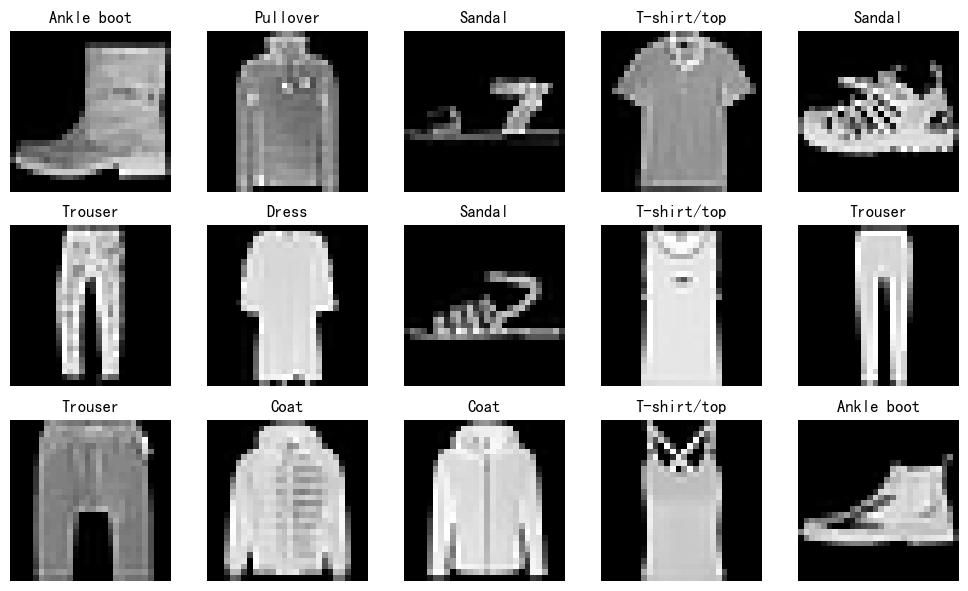

In [25]:
import matplotlib.pyplot as plt

# FashionMNIST类别名称
class_names = full_train_dataset.classes

# 可视化train_dataset前15个样本，并显示类别名称
fig, axs = plt.subplots(3, 5, figsize=(10, 6))
axs = axs.flatten()

for i in range(15):
    # 这里train_dataset[i]会返回(img, label)两个值，
    # img是第i个样本的图像（已做Tensor变换），label是对应的类别标签。
    # 因为train_dataset由torch.utils.data.random_split分割自原始的Dataset，继承了其__getitem__方法，原始FashionMNIST的__getitem__返回图像和标签两个值。
    img, label = train_dataset[i]
    img = img.squeeze().numpy()  # 变成2D numpy数组  将(1,28,28)压缩成(28,28)
    axs[i].imshow(img, cmap='gray')
    axs[i].set_title(class_names[label])
    axs[i].axis('off')

plt.tight_layout()
plt.show()

In [26]:
len(train_dataset)

55000

In [27]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

In [28]:
train_dataset[0][1]

9

In [29]:
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 300)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(300, 100)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(100, 10)
        
    def forward(self, x):
        print("Before view:", x.shape)
        x = x.view(x.size(0), -1)  # 展平成(batch_size, 784)
        print("After view:", x.shape)
        x = self.fc1(x)
        print("After fc1:", x.shape)
        x = self.relu1(x)
        print("After relu1:", x.shape)
        x = self.fc2(x)
        print("After fc2:", x.shape)
        x = self.relu2(x)
        print("After relu2:", x.shape)
        x = self.fc3(x)
        print("After fc3:", x.shape)
        return x
   

In [30]:
import torch

img, label = train_dataset[0]
img = img.unsqueeze(0)  # 增加batch维度，形状变为(1, 1, 28, 28) 或 (1, 28, 28)
model = NeuralNetwork()
output = model(img)
print("Logits:", output)
print("Predicted class:", torch.argmax(output, dim=1).item(), "True class:", label)

Before view: torch.Size([1, 1, 28, 28])
After view: torch.Size([1, 784])
After fc1: torch.Size([1, 300])
After relu1: torch.Size([1, 300])
After fc2: torch.Size([1, 100])
After relu2: torch.Size([1, 100])
After fc3: torch.Size([1, 10])
Logits: tensor([[ 0.0052, -0.0190,  0.0178,  0.0153,  0.0743,  0.0295, -0.0509,  0.0210,
          0.0486, -0.0246]], grad_fn=<AddmmBackward0>)
Predicted class: 4 True class: 9


In [31]:
for images, labels in train_loader:
    print("images shape:", images.shape) #(bs,ch,h,w)
    print("labels shape:", labels.shape) #(bs)
    break  # 只输出第一个batch

images shape: torch.Size([64, 1, 28, 28])
labels shape: torch.Size([64])


In [32]:
output = model(images)
print("Logits:", output.shape)

Before view: torch.Size([64, 1, 28, 28])
After view: torch.Size([64, 784])
After fc1: torch.Size([64, 300])
After relu1: torch.Size([64, 300])
After fc2: torch.Size([64, 100])
After relu2: torch.Size([64, 100])
After fc3: torch.Size([64, 10])
Logits: torch.Size([64, 10])


In [33]:
#输出模型的参数，及总参数量
for name, param in model.named_parameters():
    print(f"Name: {name}, Shape: {param.shape}, Number of params: {param.numel()}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Name: fc1.weight, Shape: torch.Size([300, 784]), Number of params: 235200
Name: fc1.bias, Shape: torch.Size([300]), Number of params: 300
Name: fc2.weight, Shape: torch.Size([100, 300]), Number of params: 30000
Name: fc2.bias, Shape: torch.Size([100]), Number of params: 100
Name: fc3.weight, Shape: torch.Size([10, 100]), Number of params: 1000
Name: fc3.bias, Shape: torch.Size([10]), Number of params: 10
Total number of parameters: 266610


In [34]:
300*784

235200

In [35]:
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 300)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(300, 100)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(100, 10)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)  # 展平成(batch_size, 784)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x
   
   

In [36]:
model = NeuralNetwork()

In [37]:
import torch
import torch.optim as optim

# 判断设备：如果有GPU则用GPU，否则用CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. 设置交叉熵损失函数和SGD优化器
criterion = nn.CrossEntropyLoss()  # 默认求的是样本的平均损失
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
   

Epoch [1/10], Step [100/860], Loss: 0.9379
Epoch [1/10], Step [200/860], Loss: 0.7143
Epoch [1/10], Step [300/860], Loss: 0.7691
Epoch [1/10], Step [400/860], Loss: 0.4093
Epoch [1/10], Step [500/860], Loss: 0.6517
Epoch [1/10], Step [600/860], Loss: 0.5381
Epoch [1/10], Step [700/860], Loss: 0.4057
Epoch [1/10], Step [800/860], Loss: 0.6272
Epoch [1/10], Train Loss: 0.7047, Train Acc: 79.76%, Val Loss: 0.5788, Val Acc: 79.24%
Epoch [2/10], Step [100/860], Loss: 0.2900
Epoch [2/10], Step [200/860], Loss: 0.2538
Epoch [2/10], Step [300/860], Loss: 0.2609
Epoch [2/10], Step [400/860], Loss: 0.4806
Epoch [2/10], Step [500/860], Loss: 0.4728
Epoch [2/10], Step [600/860], Loss: 0.7432
Epoch [2/10], Step [700/860], Loss: 0.2964
Epoch [2/10], Step [800/860], Loss: 0.3818
Epoch [2/10], Train Loss: 0.4354, Train Acc: 86.39%, Val Loss: 0.4044, Val Acc: 85.34%
Epoch [3/10], Step [100/860], Loss: 0.4163
Epoch [3/10], Step [200/860], Loss: 0.4549
Epoch [3/10], Step [300/860], Loss: 0.4364
Epoch [3/

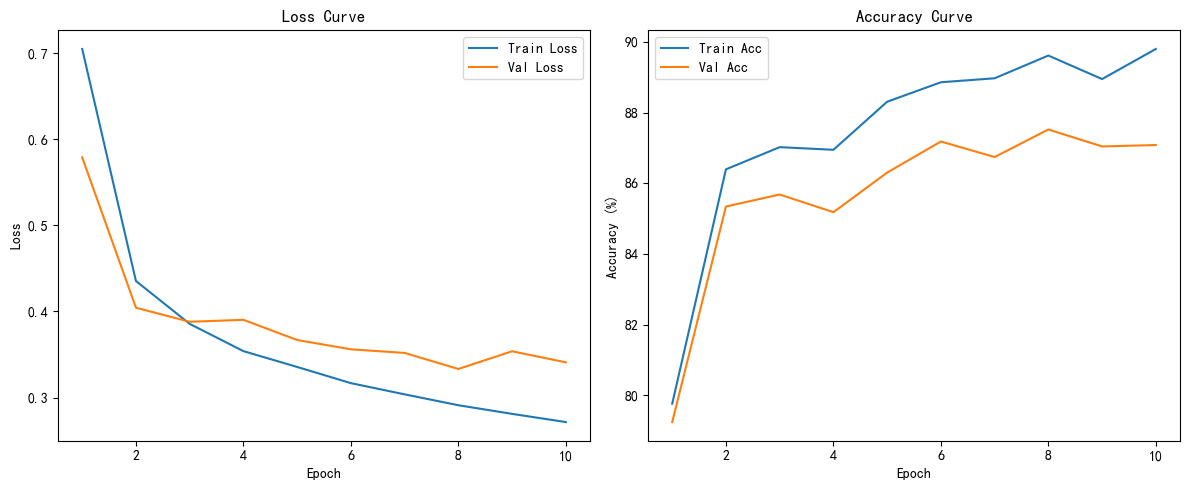

In [38]:
from model_train import Trainer

# 将模型移至设备
model.to(device)

# 初始化Trainer，进行训练
trainer = Trainer(model, train_loader, val_loader, lr=0.01, momentum=0.9, device=device)
trainer.train(epochs=10)

# 画出损失与准确率曲线
trainer.plot_metrics()


Epoch [1/50], Step [100/860], Loss: 0.9735
Epoch [1/50], Step [200/860], Loss: 0.5953
Epoch [1/50], Step [300/860], Loss: 0.5952
Epoch [1/50], Step [400/860], Loss: 0.5054
Epoch [1/50], Step [500/860], Loss: 0.3863
Epoch [1/50], Step [600/860], Loss: 0.3526
Epoch [1/50], Step [700/860], Loss: 0.3795
Epoch [1/50], Step [800/860], Loss: 0.4213
Epoch [1/50], Train Loss: 0.6980, Train Acc: 83.94%, Val Loss: 0.4854, Val Acc: 82.40%
Epoch [2/50], Step [100/860], Loss: 0.4332
Epoch [2/50], Step [200/860], Loss: 0.4011
Epoch [2/50], Step [300/860], Loss: 0.4457
Epoch [2/50], Step [400/860], Loss: 0.3963
Epoch [2/50], Step [500/860], Loss: 0.4793
Epoch [2/50], Step [600/860], Loss: 0.4004
Epoch [2/50], Step [700/860], Loss: 0.4294
Epoch [2/50], Step [800/860], Loss: 0.5916
Epoch [2/50], Train Loss: 0.4292, Train Acc: 85.85%, Val Loss: 0.4284, Val Acc: 84.98%
Epoch [3/50], Step [100/860], Loss: 0.3573
Epoch [3/50], Step [200/860], Loss: 0.2870
Epoch [3/50], Step [300/860], Loss: 0.3263
Epoch [3/

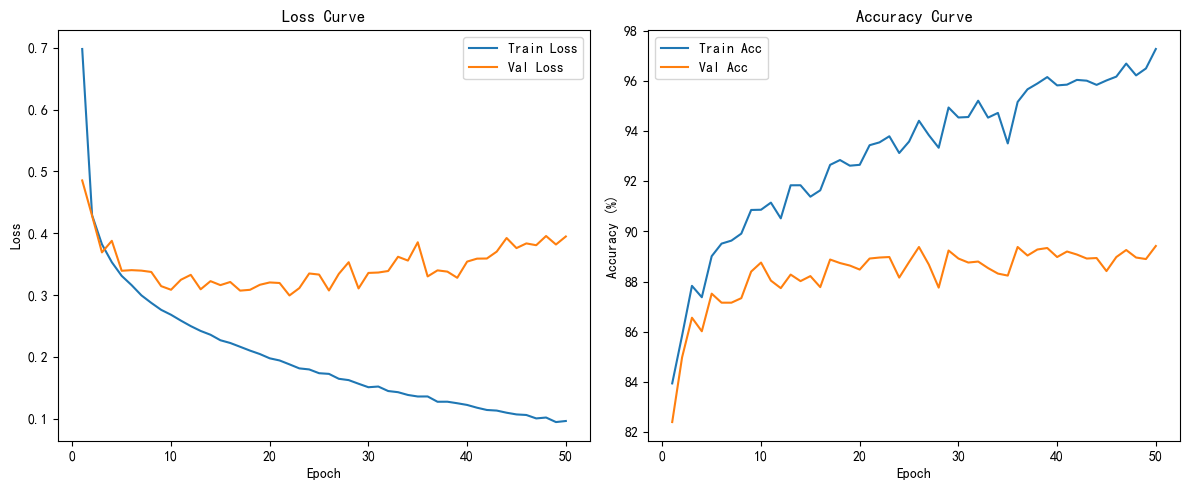

In [39]:
# 一定要重新进行模型和优化器的初始化
model = NeuralNetwork()

# 判断设备：如果有GPU则用GPU，否则用CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. 设置交叉熵损失函数和SGD优化器
criterion = nn.CrossEntropyLoss()  # 默认求的是样本的平均损失
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# 将模型移至设备
model.to(device)

# 初始化Trainer，进行训练
trainer = Trainer(model, train_loader, val_loader, lr=0.01, momentum=0.9, device=device)
trainer.train(epochs=50)

# 画出损失与准确率曲线
trainer.plot_metrics()

In [40]:
55000/64

859.375